# View MaNGA FITS from SAS downloads

Expects files produced by `download_manga_sdss.py` under **`manga_sdss_fits/<plate>_<ifu>/`**:

- **DRP `LOGCUBE`** — 3D spectral cube + `WAVE` + reconstructed **GIMG/RIMG/IIMG/ZIMG** (+ PSFs)
- **DAP `MAPS`** — many 2D map extensions (emission lines, stellar kinematics, …)
- **DAP model `LOGCUBE`** — model spectral cube for the same DAP run
- **Pipe3D VAC cube** (`*.Pipe3D.cube.fits.gz`) — derived stellar-population products (mass/metallicity/SFH-style maps)

Install if needed: `pip install astropy matplotlib numpy`

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.utils.exceptions import AstropyWarning

warnings.filterwarnings("ignore", category=AstropyWarning)

# Match download_manga_sdss.py defaults
DATA_ROOT = Path("manga_sdss_fits")
PLATE_IFU = "8485-1901"  # change me

GAL_DIR = DATA_ROOT / PLATE_IFU.replace("-", "_")
assert GAL_DIR.is_dir(), f"Missing {GAL_DIR} — run download script first or fix PLATE_IFU"

files = sorted(GAL_DIR.glob("*.fits*"))
for p in files:
    print(p.name, f"({p.stat().st_size / (1024**2):.1f} MiB)")

manga-8485-1901-LOGCUBE-HYB10-MILESHC-MASTARHC2.fits.gz (19.9 MiB)
manga-8485-1901-LOGCUBE.fits.gz (37.1 MiB)
manga-8485-1901-MAPS-HYB10-MILESHC-MASTARHC2.fits.gz (1.5 MiB)
manga-8485-1901.Pipe3D.cube.fits.gz (7.5 MiB)


In [2]:
def find_file(keyword: str) -> Path:
    hits = [p for p in files if keyword.lower() in p.name.lower()]
    if not hits:
        raise FileNotFoundError(f"no file matching {keyword!r} in {GAL_DIR}")
    return hits[0]


def hdul_summary(h: fits.HDUList, max_ext: int = 40) -> None:
    print(f"{'HDU':>4} {'Type':12} {'Name':24} shape / info")
    print("-" * 72)
    for i, hdu in enumerate(h[:max_ext]):
        name = hdu.name or "(no name)"
        cls = type(hdu).__name__[:10]
        if hasattr(hdu, "data") and hdu.data is not None:
            shp = getattr(hdu.data, "shape", "")
            extra = f"shape={shp}"
        else:
            extra = "(no data)"
        print(f"{i:4d} {cls:12} {name:24} {extra}")
    if len(h) > max_ext:
        print(f"... {len(h) - max_ext} more HDUs")


def plot_image2d(
    data,
    title: str,
    ax=None,
    origin: str = "lower",
    percentile_clip=(1, 99),
):
    """Robust imshow with percentile scaling for noisy maps."""
    d = np.asarray(data, dtype=float)
    finite = np.isfinite(d) & (d != 0)
    if not finite.any():
        lo, hi = np.nanmin(d), np.nanmax(d)
    else:
        lo, hi = np.percentile(d[finite], percentile_clip)
        if lo == hi:
            lo, hi = float(np.nanmin(d)), float(np.nanmax(d))
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(d, origin=origin, vmin=lo, vmax=hi, cmap="viridis")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    return ax

## 1) DRP `LOGCUBE` — cube, wavelength, griz images

In [3]:
# DRP datacube only (exclude MAPS file and DAP model LOGCUBE-*)
cands = [
    p
    for p in files
    if "LOGCUBE" in p.name.upper()
    and "MAPS" not in p.name.upper()
    and "LOGCUBE-" not in p.name
]
if not cands:
    raise FileNotFoundError(f"No DRP LOGCUBE in {GAL_DIR}")
drp_cube_path = cands[0]

print("DRP cube:", drp_cube_path.name)

with fits.open(drp_cube_path, memmap=True) as h:
    hdul_summary(h)

h_drp = fits.open(drp_cube_path, memmap=True)
flux = h_drp["FLUX"].data
wave = h_drp["WAVE"].data
print("FLUX shape (expect λ × y × x or similar):", flux.shape)
print("WAVE shape:", wave.shape, "range:", float(np.nanmin(wave)), "–", float(np.nanmax(wave)), "Å")

DRP cube: manga-8485-1901-LOGCUBE.fits.gz
 HDU Type         Name                     shape / info
------------------------------------------------------------------------
   0 PrimaryHDU   PRIMARY                  (no data)
   1 ImageHDU     FLUX                     shape=(4563, 34, 34)
   2 ImageHDU     IVAR                     shape=(4563, 34, 34)
   3 ImageHDU     MASK                     shape=(4563, 34, 34)
   4 ImageHDU     LSFPOST                  shape=(4563, 34, 34)
   5 ImageHDU     LSFPRE                   shape=(4563, 34, 34)
   6 ImageHDU     WAVE                     shape=(4563,)
   7 ImageHDU     SPECRES                  shape=(4563,)
   8 ImageHDU     SPECRESD                 shape=(4563,)
   9 ImageHDU     PRESPECRES               shape=(4563,)
  10 ImageHDU     PRESPECRESD              shape=(4563,)
  11 BinTableHD   OBSINFO                  shape=(9,)
  12 ImageHDU     GIMG                     shape=(34, 34)
  13 ImageHDU     RIMG                     shape=(34, 34)
 

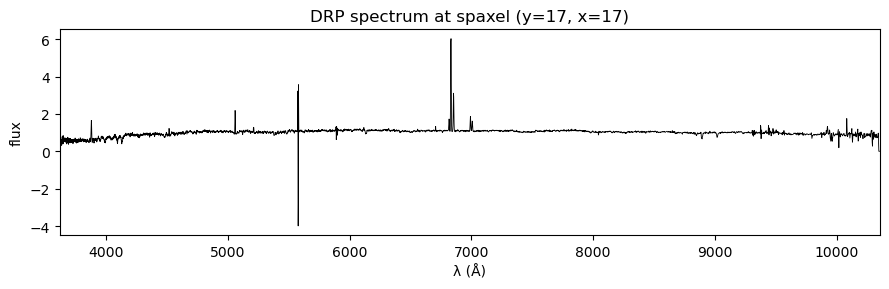

In [4]:
# Pick central spaxel and plot a 1D spectrum
nz, ny, nx = flux.shape
cy, cx = ny // 2, nx // 2
spec = flux[:, cy, cx]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(wave, spec, lw=0.6, color="k")
ax.set_xlabel("λ (Å)")
ax.set_ylabel("flux")
ax.set_title(f"DRP spectrum at spaxel (y={cy}, x={cx})")
ax.set_xlim(float(wave.min()), float(wave.max()))
plt.tight_layout()
plt.show()

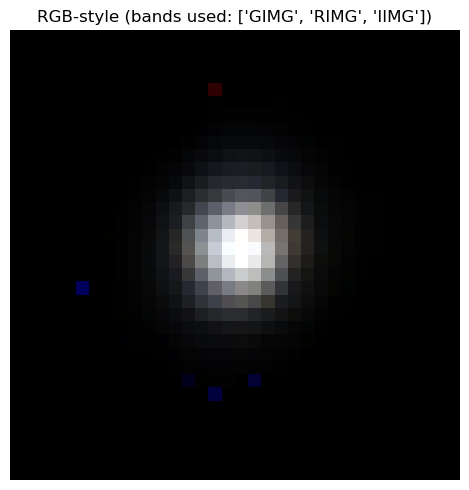

In [5]:
# Pseudocolor RGB from GIMG, RIMG, IIMG (or first three *IMG* HDUs found)
img_names = ["GIMG", "RIMG", "IIMG"]
channels = []
used = []
for nm in img_names:
    if nm in h_drp:
        channels.append(np.asarray(h_drp[nm].data, dtype=float))
        used.append(nm)

if len(channels) < 3:
    # fallback: any extension ending in IMG
    extra = [(hdu.name, hdu.data) for hdu in h_drp if hdu.name and "IMG" in hdu.name and hdu.data is not None]
    print("HDUs with IMG in name:", [n for n, _ in extra[:8]])
    channels = [np.asarray(d, dtype=float) for _, d in extra[:3]]
    used = [n for n, _ in extra[:3]]

if len(channels) == 3:
    def norm01(x):
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        lo, hi = np.percentile(x[x > 0] if (x > 0).any() else x, [5, 99.5])
        return np.clip((x - lo) / (hi - lo + 1e-10), 0, 1)

    rgb = np.stack([norm01(channels[2]), norm01(channels[1]), norm01(channels[0])], axis=-1)  # I,R,G → R,G,B tweaking
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(rgb, origin="lower")
    ax.set_title(f"RGB-style (bands used: {used})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Could not find 3 broadband image HDUs; inspect hdul_summary above.")

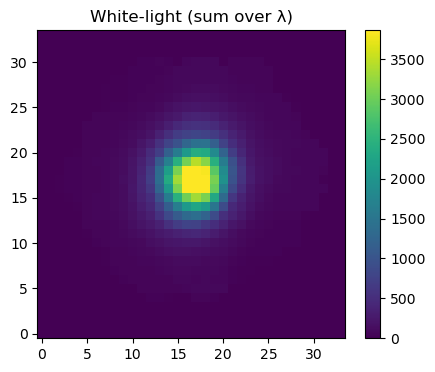

In [6]:
# Collapsed white-light image: median or sum along wavelength
collapse = np.nansum(flux, axis=0)
fig, ax = plt.subplots(figsize=(5, 4))
plot_image2d(collapse, "White-light (sum over λ)", ax=ax)
plt.show()

## 2) DAP `MAPS` — browse 2D map extensions

In [7]:
maps_path = find_file("MAPS")
print("MAPS:", maps_path.name)

with fits.open(maps_path, memmap=True) as h:
    hdul_summary(h, max_ext=25)

h_maps = fits.open(maps_path, memmap=True)
h_mod = None  # set in DAP model cell if present

#print all names
for hdu in h_maps:
    print(hdu.name)


MAPS: manga-8485-1901-MAPS-HYB10-MILESHC-MASTARHC2.fits.gz
 HDU Type         Name                     shape / info
------------------------------------------------------------------------
   0 PrimaryHDU   PRIMARY                  (no data)
   1 ImageHDU     SPX_SKYCOO               shape=(2, 34, 34)
   2 ImageHDU     SPX_ELLCOO               shape=(4, 34, 34)
   3 ImageHDU     SPX_MFLUX                shape=(34, 34)
   4 ImageHDU     SPX_MFLUX_IVAR           shape=(34, 34)
   5 ImageHDU     SPX_SNR                  shape=(34, 34)
   6 ImageHDU     BINID                    shape=(5, 34, 34)
   7 ImageHDU     BIN_LWSKYCOO             shape=(2, 34, 34)
   8 ImageHDU     BIN_LWELLCOO             shape=(4, 34, 34)
   9 ImageHDU     BIN_AREA                 shape=(34, 34)
  10 ImageHDU     BIN_FAREA                shape=(34, 34)
  11 ImageHDU     BIN_MFLUX                shape=(34, 34)
  12 ImageHDU     BIN_MFLUX_IVAR           shape=(34, 34)
  13 ImageHDU     BIN_MFLUX_MASK           shape

Found 15 image-like HDUs (showing up to 8)


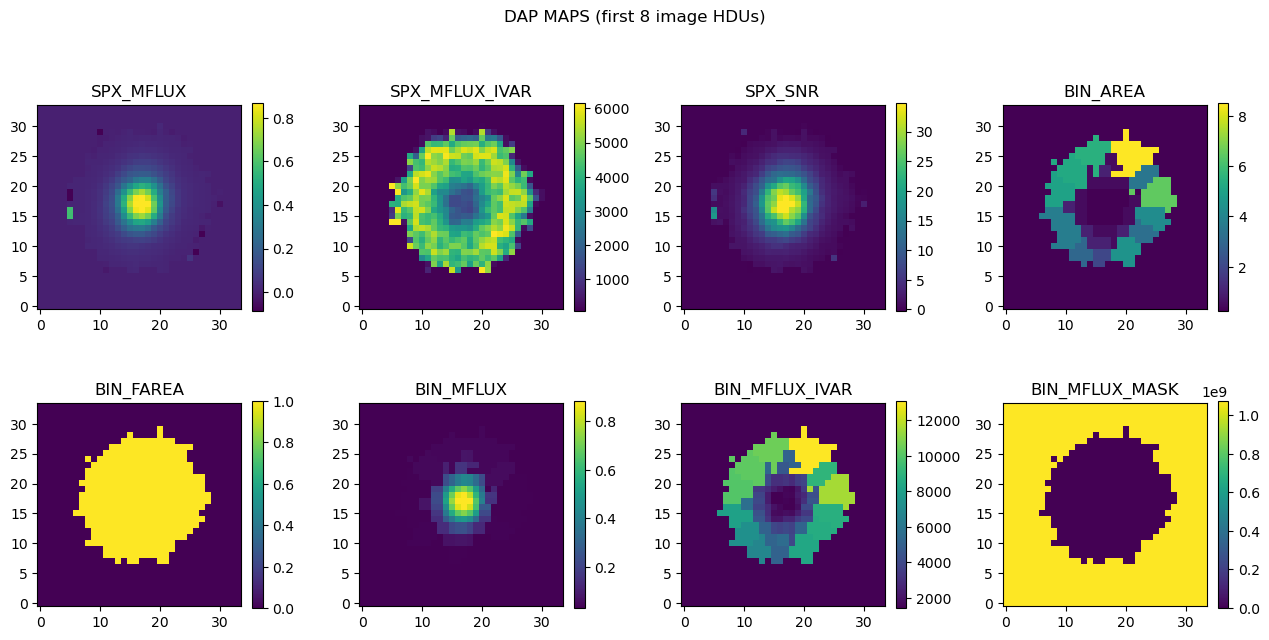

In [8]:
# Plot first few 2D image HDUs (skip PRIMARY)
plot_hdu_names = []
for hdu in h_maps:
    if hdu.data is None:
        continue
    d = np.asarray(hdu.data)
    if d.ndim == 2 and hdu.name and hdu.name != "PRIMARY":
        plot_hdu_names.append(hdu.name)

print(f"Found {len(plot_hdu_names)} image-like HDUs (showing up to 8)")
nshow = min(8, len(plot_hdu_names))
ncols = 4
nrows = int(np.ceil(nshow / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, plot_hdu_names[:nshow]):
    plot_image2d(h_maps[name].data, name, ax=ax)
for ax in axes[nshow:]:
    ax.axis("off")
plt.suptitle("DAP MAPS (first 8 image HDUs)", y=1.02)
plt.tight_layout()
plt.show()

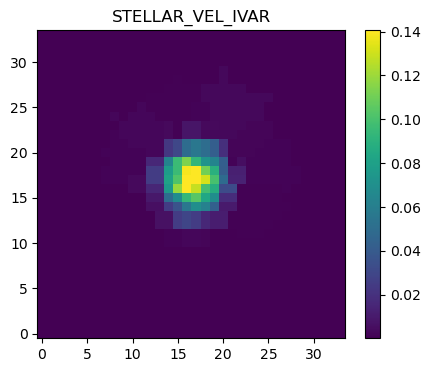

In [9]:
# Pick one map by name (edit to explore)
MAP_NAME = plot_hdu_names[10] if plot_hdu_names else None
if MAP_NAME:
    fig, ax = plt.subplots(figsize=(5, 4))
    plot_image2d(h_maps[MAP_NAME].data, MAP_NAME, ax=ax)
    plt.show()

## 3) DAP model `LOGCUBE` (if downloaded)

DAP model cube: manga-8485-1901-LOGCUBE-HYB10-MILESHC-MASTARHC2.fits.gz
 HDU Type         Name                     shape / info
------------------------------------------------------------------------
   0 PrimaryHDU   PRIMARY                  (no data)
   1 ImageHDU     FLUX                     shape=(4563, 34, 34)
   2 ImageHDU     IVAR                     shape=(4563, 34, 34)
   3 ImageHDU     MASK                     shape=(4563, 34, 34)
   4 ImageHDU     LSF                      shape=(4563, 34, 34)
   5 ImageHDU     WAVE                     shape=(4563,)
   6 ImageHDU     REDCORR                  shape=(4563,)
   7 ImageHDU     MODEL                    shape=(4563, 34, 34)
   8 ImageHDU     MODEL_MASK               shape=(4563, 34, 34)
   9 ImageHDU     EMLINE                   shape=(4563, 34, 34)
  10 ImageHDU     STELLAR                  shape=(4563, 34, 34)
  11 ImageHDU     STELLAR_MASK             shape=(4563, 34, 34)
  12 ImageHDU     BINID                    shape=(5, 34,

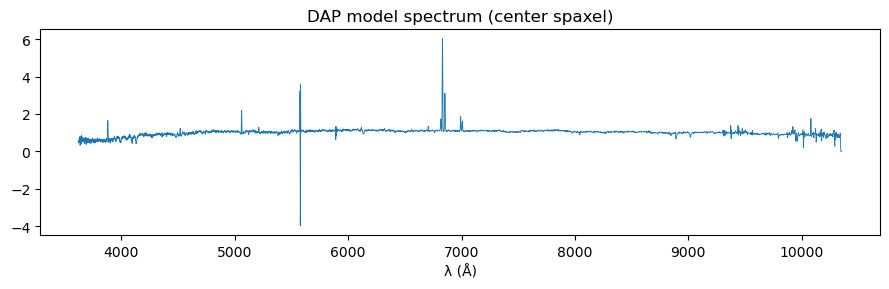

In [10]:
h_mod = None
# DAP model cube filename contains "LOGCUBE-<DAPTYPE>" (hyphen after LOGCUBE)
dap_model = next((p for p in files if "LOGCUBE-" in p.name and p.suffix.lower() in (".gz", ".fits")), None)

if dap_model is not None and dap_model.resolve() != drp_cube_path.resolve():
    print("DAP model cube:", dap_model.name)
    h_mod = fits.open(dap_model, memmap=True)
    hdul_summary(h_mod, max_ext=20)
    f_mod = h_mod["FLUX"].data
    w_mod = h_mod["WAVE"].data
    nz, ny, nx = f_mod.shape
    cy, cx = ny // 2, nx // 2
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(w_mod, f_mod[:, cy, cx], lw=0.6)
    ax.set_xlabel("λ (Å)")
    ax.set_title("DAP model spectrum (center spaxel)")
    plt.tight_layout()
    plt.show()
else:
    print("No separate DAP model LOGCUBE found (download with default --what all).")
    h_mod = None

## 4) Pipe3D VAC (stellar populations: mass, SFR history, metallicity)

This section opens the per-galaxy Pipe3D VAC file from `download_manga_sdss.py`.

- Filename pattern: `manga-<plate>-<ifu>.Pipe3D.cube.fits.gz`
- Pipe3D contains many products; extension names can differ by release.
- The helper below auto-finds likely maps by keywords and plots 2D slices where possible.

In [16]:
# Print full Pipe3D channel metadata from FITS headers
# This is where DESC_* comes from: header cards in each extension.
if 'h_p3d' not in globals() or not isinstance(h_p3d, fits.HDUList):
    print("Run the previous Pipe3D open cell first.")
else:
    def print_desc_table(hdul, extname):
        if extname not in hdul:
            print(f"[{extname}] not present")
            return
        hdr = hdul[extname].header
        desc_items = []
        for k, v in hdr.items():
            if k.startswith("DESC_"):
                try:
                    idx = int(k.split("_")[1])
                except Exception:
                    continue
                desc_items.append((idx, str(v).strip()))
        desc_items.sort(key=lambda x: x[0])

        print(f"\n[{extname}] shape={np.asarray(hdul[extname].data).shape}")
        if not desc_items:
            print("  No DESC_* entries found.")
            return
        for idx, text in desc_items:
            print(f"  {idx:3d}: {text}")

    print_desc_table(h_p3d, "SSP")
    print_desc_table(h_p3d, "SFH")
    print_desc_table(h_p3d, "ELINES")

    # Optional: FLUX_ELINES uses NAME* header keys (different schema than DESC_*).
    if "FLUX_ELINES" in h_p3d:
        hdr = h_p3d["FLUX_ELINES"].header
        name_items = []
        for k, v in hdr.items():
            if k.startswith("NAME"):
                s = k[4:]
                if s.isdigit():
                    name_items.append((int(s), str(v).strip()))
        name_items.sort(key=lambda x: x[0])
        print(f"\n[FLUX_ELINES] total NAME* entries: {len(name_items)}")
        print("  First 40 entries:")
        for idx, text in name_items[:455]:
            print(f"  {idx:3d}: {text}")


[SSP] shape=(21, 34, 34)
    0: pseudo V-band map
    1: continuum segmentation file
    2: continuum dezonification file
    3: median intensity flux within the wavelength range
    4: StdDev median intensity flux within the wavelength range
    5: luminosity weighted age of the stellar population
    6: mass weighted age of the stellar population
    7: error of the age of the stellar population
    8: luminosity weighted metallicity of the stellar population
    9: mass weighted metallicity of the stellar population
   10: error metallicity of the stellar population
   11: average dust attnuation of the stellar population
   12: error of the average dust attnuation of the stellar population
   13: velocity of the stellar population
   14: error in the velocity of the stellar population
   15: velocity dispersion of the stellar population
   16: error in velocity dispersion of the stellar population
   17: average mass-to-light ratio of the stellar population
   18: stellar mass den

Pipe3D: manga-8485-1901.Pipe3D.cube.fits.gz
 HDU Type         Name                     shape / info
------------------------------------------------------------------------
   0 PrimaryHDU   ORG_HDR                  (no data)
   1 ImageHDU     SSP                      shape=(21, 34, 34)
   2 ImageHDU     SFH                      shape=(319, 34, 34)
   3 ImageHDU     INDICES                  shape=(18, 34, 34)
   4 ImageHDU     ELINES                   shape=(11, 34, 34)
   5 ImageHDU     FLUX_ELINES              shape=(456, 34, 34)
   6 ImageHDU     FLUX_ELINES_LONG         shape=(1536, 34, 34)
   7 ImageHDU     GAIA_MASK                shape=(34, 34)
   8 ImageHDU     SELECT_REG               shape=(34, 34)


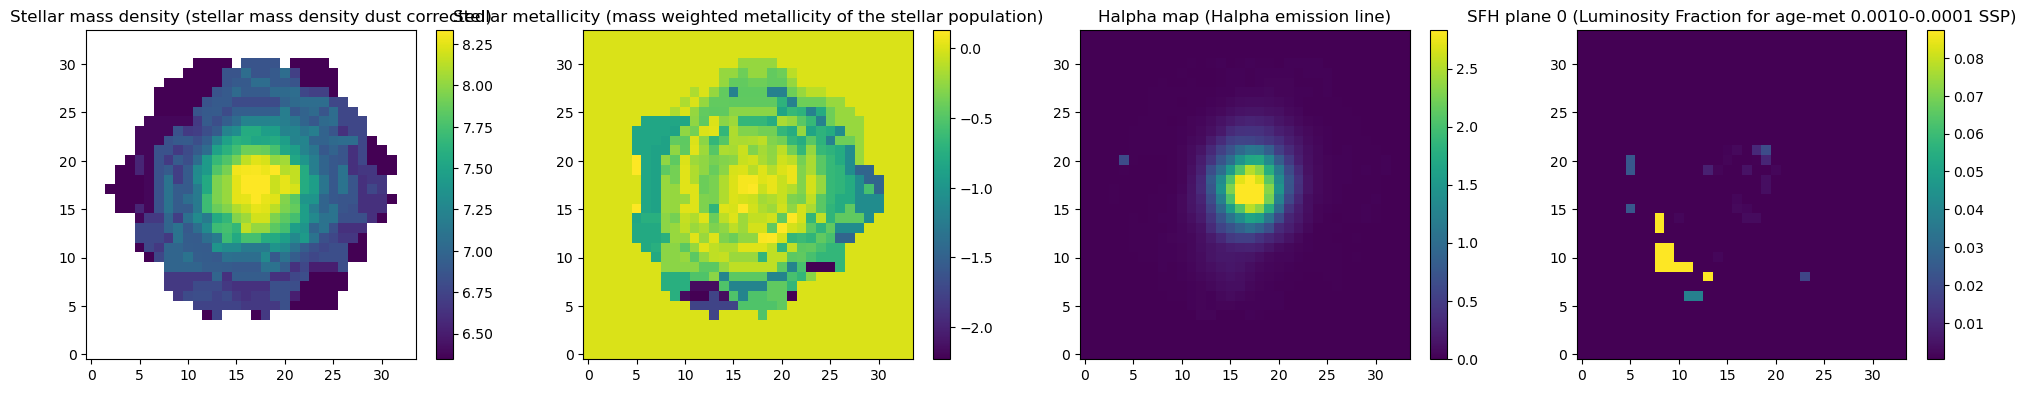

In [12]:
# Find and inspect Pipe3D VAC file
pipe3d_path = next((p for p in files if ".Pipe3D.cube" in p.name), None)
if pipe3d_path is None:
    print("No Pipe3D VAC file found. Re-run download with default --what all (or without --no-pipe3d-vac).")
else:
    print("Pipe3D:", pipe3d_path.name)
    h_p3d = fits.open(pipe3d_path, memmap=True)
    hdul_summary(h_p3d)

    def _desc_index_by_substring(header, needle):
        needle = needle.lower()
        for k, v in header.items():
            if not k.startswith("DESC_"):
                continue
            if needle in str(v).lower():
                return int(k.split("_")[1]), str(v)
        return None, None

    maps = []

    # 1) Stellar mass density and metallicity from SSP channels.
    if "SSP" in h_p3d and h_p3d["SSP"].data is not None:
        ssp = np.asarray(h_p3d["SSP"].data)
        hdr = h_p3d["SSP"].header

        idx_mass, desc_mass = _desc_index_by_substring(hdr, "stellar mass density dust corrected")
        if idx_mass is None:
            idx_mass, desc_mass = _desc_index_by_substring(hdr, "stellar mass density")
        if idx_mass is not None and idx_mass < ssp.shape[0]:
            maps.append((ssp[idx_mass], f"Stellar mass density ({desc_mass.strip()})"))
        else:
            print("Could not locate SSP stellar-mass channel from DESC_* metadata.")

        idx_met, desc_met = _desc_index_by_substring(hdr, "mass weighted metallicity")
        if idx_met is None:
            idx_met, desc_met = _desc_index_by_substring(hdr, "metallicity")
        if idx_met is not None and idx_met < ssp.shape[0]:
            maps.append((ssp[idx_met], f"Stellar metallicity ({desc_met.strip()})"))
        else:
            print("Could not locate SSP metallicity channel from DESC_* metadata.")

    # 2) SFR proxy from ELINES Halpha map.
    # This is a practical proxy, not a dust-corrected physical SFR map.
    if "ELINES" in h_p3d and h_p3d["ELINES"].data is not None:
        el = np.asarray(h_p3d["ELINES"].data)
        hdr = h_p3d["ELINES"].header
        idx_ha, desc_ha = _desc_index_by_substring(hdr, "halpha emission line")
        if idx_ha is not None and idx_ha < el.shape[0]:
            maps.append((el[idx_ha], f"Halpha map ({desc_ha.strip()})"))
        else:
            print("Could not locate Halpha map in ELINES DESC_* metadata.")

    # 3) Show one SFH plane to inspect resolved star-formation-history channels.
    if "SFH" in h_p3d and h_p3d["SFH"].data is not None:
        sfh = np.asarray(h_p3d["SFH"].data)
        sfh_desc = h_p3d["SFH"].header.get("DESC_0", "SFH plane 0")
        maps.append((sfh[0], f"SFH plane 0 ({sfh_desc})"))

    if maps:
        n = len(maps)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        if n == 1:
            axes = [axes]
        for ax, (m, title) in zip(axes, maps):
            plot_image2d(m, title, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        print("No Pipe3D 2D maps selected. Inspect DESC_* metadata and pick channels manually.")

## 5) SDSS cutouts (color JPEG + ugriz FITS)

This section reads files created by `download_sdss_cutouts.py` in:

- `manga_sdss_fits/<plate>_<ifu>/sdss_cutouts/`

Expected files:
- `sdss-<plate>-<ifu>-color.jpg`
- `sdss-<plate>-<ifu>-u.fits`, `-g.fits`, `-r.fits`, `-i.fits`, `-z.fits`

Cutout dir: manga_sdss_fits\8485_1901\sdss_cutouts


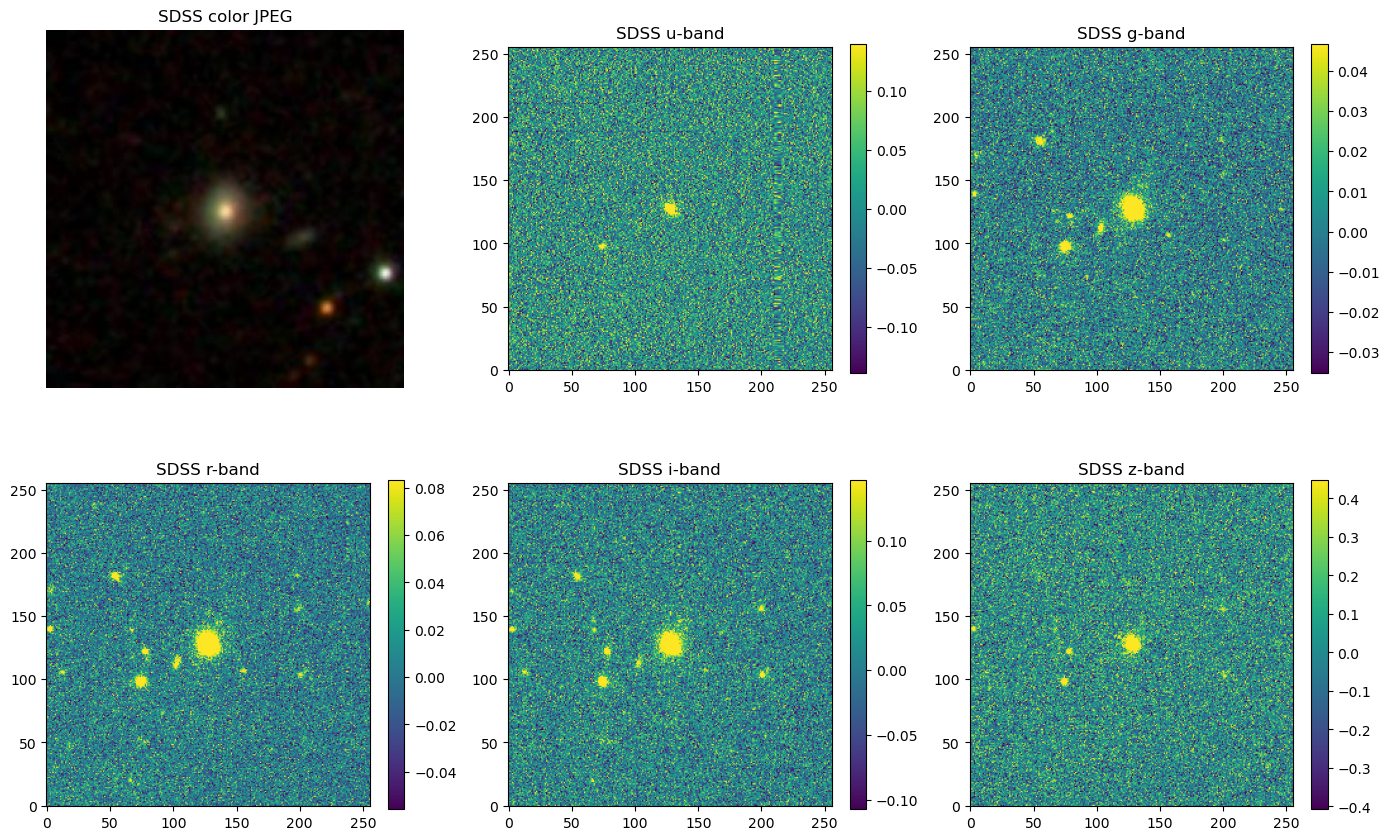

In [13]:
# Show SDSS color JPEG + ugriz FITS cutouts
cut_dir = GAL_DIR / "sdss_cutouts"
print("Cutout dir:", cut_dir)

plate, ifu = PLATE_IFU.split("-")
jpeg_path = cut_dir / f"sdss-{plate}-{ifu}-color.jpg"

bands = ["u", "g", "r", "i", "z"]
fit_paths = {b: cut_dir / f"sdss-{plate}-{ifu}-{b}.fits" for b in bands}

if not cut_dir.is_dir():
    print("No sdss_cutouts directory found. Run download_sdss_cutouts.py first.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.ravel()

    # Panel 1: color JPEG
    ax0 = axes[0]
    if jpeg_path.exists():
        rgb = plt.imread(jpeg_path)
        ax0.imshow(rgb, origin="upper")
        ax0.set_title("SDSS color JPEG")
        ax0.axis("off")
    else:
        ax0.text(0.5, 0.5, "Missing color JPEG", ha="center", va="center")
        ax0.set_axis_off()

    # Panels 2-6: ugriz FITS
    for i, b in enumerate(bands, start=1):
        ax = axes[i]
        p = fit_paths[b]
        if p.exists():
            arr = fits.getdata(p)
            plot_image2d(arr, f"SDSS {b}-band", ax=ax)
        else:
            ax.text(0.5, 0.5, f"Missing {b}-band FITS", ha="center", va="center")
            ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [14]:
# Close memmapped handles (helps on Windows with file locks)
for _h in (h_drp, h_maps, h_mod, globals().get("h_p3d", None)):
    if isinstance(_h, fits.HDUList):
        try:
            _h.close()
        except Exception:
            pass
print("Closed HDUList handles.")

Closed HDUList handles.


## 6) Spectral indices search (DAP MAPS + Pipe3D INDICES)

This section scans index metadata and channels to find `D4000/Dn4000` and other index-like quantities.
It prints all discovered channel labels and plots matches when available.

MAPS: manga-8485-1901-MAPS-HYB10-MILESHC-MASTARHC2.fits.gz

[DAP MAPS SPECINDEX] channels found: 46
     1 (C01): CN1
     2 (C02): CN2
     3 (C03): Ca4227
     4 (C04): G4300
     5 (C05): Fe4383
     6 (C06): Ca4455
     7 (C07): Fe4531
     8 (C08): C24668
     9 (C09): Hb
    10 (C10): Fe5015
    11 (C11): Mg1
    12 (C12): Mg2
    13 (C13): Mgb
    14 (C14): Fe5270
    15 (C15): Fe5335
    16 (C16): Fe5406
    17 (C17): Fe5709
    18 (C18): Fe5782
    19 (C19): NaD
    20 (C20): TiO1
    21 (C21): TiO2
    22 (C22): HDeltaA
    23 (C23): HGammaA
    24 (C24): HDeltaF
    25 (C25): HGammaF
    26 (C26): CaHK
    27 (C27): CaII1
    28 (C28): CaII2
    29 (C29): CaII3
    30 (C30): Pa17
    31 (C31): Pa14
    32 (C32): Pa12
    33 (C33): MgICvD
    34 (C34): NaICvD
    35 (C35): MgIIR
    36 (C36): FeHCvD
    37 (C37): NaI
    38 (C38): bTiO
    39 (C39): aTiO
    40 (C40): CaH1
    41 (C41): CaH2
    42 (C42): NaISDSS
    43 (C43): TiO2SDSS
    44 (C44): D4000
    45 (C45): Dn4000

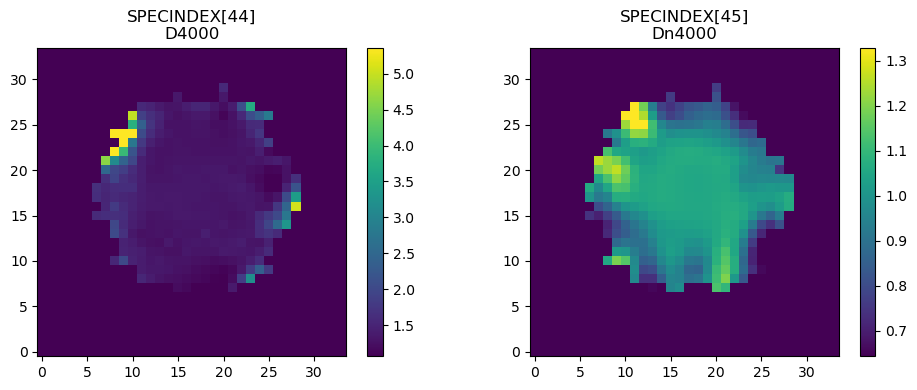


Pipe3D: manga-8485-1901.Pipe3D.cube.fits.gz

[Pipe3D INDICES] channels found: 0
No D4000-like labels found in Pipe3D INDICES labels.


In [17]:
import re


def _extract_channel_labels_from_header(hdr):
    """Return list of (raw_idx, label, key) from common header schemas."""
    out = []
    for k, v in hdr.items():
        s = str(v).strip()
        if not s:
            continue

        ku = k.upper()
        m = None
        if ku.startswith("DESC_"):
            m = re.match(r"DESC_(\d+)$", ku)
            if m:
                out.append((int(m.group(1)), s, k))
                continue
        if ku.startswith("NAME"):
            m = re.match(r"NAME(\d+)$", ku)
            if m:
                out.append((int(m.group(1)), s, k))
                continue
        # DAP MAPS sometimes stores channel labels as C01, C1, etc.
        m = re.match(r"C(\d+)$", ku)
        if m and not ku.startswith("CR"):
            out.append((int(m.group(1)), s, k))

    out.sort(key=lambda x: x[0])
    return out


def _to_zero_based(raw_idx, nchan):
    """Handle both 0-based and 1-based header channel numbering."""
    if 0 <= raw_idx < nchan:
        return raw_idx
    if 1 <= raw_idx <= nchan:
        return raw_idx - 1
    return None


def _print_channel_list(title, labels, max_lines=500):
    print(f"\n[{title}] channels found: {len(labels)}")
    for i, (raw_idx, label, key) in enumerate(labels[:max_lines]):
        print(f"  {raw_idx:4d} ({key}): {label}")
    if len(labels) > max_lines:
        print(f"  ... {len(labels) - max_lines} more")


# --- A) DAP MAPS SPECINDEX search ---
try:
    maps_path = find_file("MAPS")
except Exception:
    maps_path = None

if maps_path is None:
    print("No MAPS file found.")
else:
    print("MAPS:", maps_path.name)
    with fits.open(maps_path, memmap=True) as hm:
        if "SPECINDEX" in hm and hm["SPECINDEX"].data is not None:
            sidx = np.asarray(hm["SPECINDEX"].data)
            shdr = hm["SPECINDEX"].header
            labels = _extract_channel_labels_from_header(shdr)
            _print_channel_list("DAP MAPS SPECINDEX", labels)

            # Look for D4000 / Dn4000-like labels.
            hits = [(ri, lb, ky) for (ri, lb, ky) in labels if re.search(r"D\s*N?\s*4000|DN4000", lb, flags=re.IGNORECASE)]
            if not hits:
                print("No D4000-like labels found in SPECINDEX header labels.")
            else:
                print("\nD4000-like matches in SPECINDEX:")
                for raw_idx, label, key in hits:
                    z = _to_zero_based(raw_idx, sidx.shape[0])
                    print(f"  raw={raw_idx}, zero_based={z}, key={key}, label={label}")

                plot_hits = [(raw_idx, label) for raw_idx, label, _ in hits][:6]
                fig, axes = plt.subplots(1, len(plot_hits), figsize=(5 * len(plot_hits), 4))
                if len(plot_hits) == 1:
                    axes = [axes]
                for ax, (raw_idx, label) in zip(axes, plot_hits):
                    z = _to_zero_based(raw_idx, sidx.shape[0])
                    if z is None:
                        ax.text(0.5, 0.5, f"Index {raw_idx} out of range", ha="center", va="center")
                        ax.set_axis_off()
                    else:
                        plot_image2d(sidx[z], f"SPECINDEX[{z}]\n{label}", ax=ax)
                plt.tight_layout()
                plt.show()
        else:
            print("MAPS has no SPECINDEX extension (or it is empty).")


# --- B) Pipe3D INDICES search ---
pipe3d_path = next((p for p in files if ".Pipe3D.cube" in p.name), None)
if pipe3d_path is None:
    print("\nNo Pipe3D VAC file found.")
else:
    print("\nPipe3D:", pipe3d_path.name)
    with fits.open(pipe3d_path, memmap=True) as hp:
        if "INDICES" in hp and hp["INDICES"].data is not None:
            iarr = np.asarray(hp["INDICES"].data)
            ihdr = hp["INDICES"].header
            ilabels = _extract_channel_labels_from_header(ihdr)
            _print_channel_list("Pipe3D INDICES", ilabels)

            ihits = [(ri, lb, ky) for (ri, lb, ky) in ilabels if re.search(r"D\s*N?\s*4000|DN4000", lb, flags=re.IGNORECASE)]
            if not ihits:
                print("No D4000-like labels found in Pipe3D INDICES labels.")
            else:
                print("\nD4000-like matches in Pipe3D INDICES:")
                for raw_idx, label, key in ihits:
                    z = _to_zero_based(raw_idx, iarr.shape[0])
                    print(f"  raw={raw_idx}, zero_based={z}, key={key}, label={label}")

                plot_hits = [(raw_idx, label) for raw_idx, label, _ in ihits][:6]
                fig, axes = plt.subplots(1, len(plot_hits), figsize=(5 * len(plot_hits), 4))
                if len(plot_hits) == 1:
                    axes = [axes]
                for ax, (raw_idx, label) in zip(axes, plot_hits):
                    z = _to_zero_based(raw_idx, iarr.shape[0])
                    if z is None:
                        ax.text(0.5, 0.5, f"Index {raw_idx} out of range", ha="center", va="center")
                        ax.set_axis_off()
                    else:
                        plot_image2d(iarr[z], f"INDICES[{z}]\n{label}", ax=ax)
                plt.tight_layout()
                plt.show()
        else:
            print("Pipe3D has no INDICES extension (or it is empty).")